# Leaf-Only EfficientNet-B0 Teacher

**Backbone:** EfficientNet-B0 (ImageNet pretrained)  
**Training view:** `leaf_only`  
**Classes:** 38  
**Model selection:** Validation Macro F1

This notebook uses the corrected classification dataset:

- 54,304 samples
- 43,443 train
- 5,430 validation
- 5,431 test
- all 38 classes represented in the test set

It is auto-resumable from `last_checkpoint.pth`.

The Standard RGB baseline and Leaf-Only Teacher are independent, so they may be trained simultaneously in separate authorized Colab accounts if each account has the same finalized classification artifacts and usage complies with Colab terms and quotas.


# STEP 1 — Install and Import

In [1]:
!pip -q install kagglehub scikit-learn

import gc
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import kagglehub
from tqdm.auto import tqdm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

if DEVICE.type != "cuda":
    raise RuntimeError("Enable a T4 GPU before running.")

print("GPU:", torch.cuda.get_device_name(0))


GPU: Tesla T4


# STEP 2 — Download PlantVillage and Detect Root

In [2]:
download_path = Path(
    kagglehub.dataset_download(
        "abdallahalidev/plantvillage-dataset"
    )
)

def find_dataset_root(base):
    required = {"color","grayscale","segmented"}
    candidates = [base] + [p for p in base.rglob("*") if p.is_dir()]

    for path in candidates:
        try:
            names = {p.name for p in path.iterdir() if p.is_dir()}
            if required.issubset(names):
                return path
        except PermissionError:
            pass

    return None

dataset_root = find_dataset_root(download_path)

assert dataset_root is not None

print("Dataset root:", dataset_root)


Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Dataset root: /kaggle/input/plantvillage-dataset/plantvillage dataset


# STEP 3 — Mount Drive and Verify Final Artifacts

In [3]:
from google.colab import drive

drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/PlantVillage_Classification"
)

MANIFEST_PATH = PROJECT_DIR/"final_classification_manifest_v2.csv"
CLASS_MAP_PATH = PROJECT_DIR/"classification_class_map_v2.json"
MASK_ARCHIVE = PROJECT_DIR/"classification_unet_masks_packed.npz"

for path in [MANIFEST_PATH, CLASS_MAP_PATH, MASK_ARCHIVE]:
    print("✅" if path.exists() else "❌", path)
    assert path.exists()

df = pd.read_csv(MANIFEST_PATH)

with open(CLASS_MAP_PATH,"r") as f:
    class_map = json.load(f)

CLASS_NAMES = [
    class_map["id_to_class"][str(i)]
    for i in range(38)
]

assert len(df) == 54304
assert (df["split"]=="train").sum() == 43443
assert (df["split"]=="val").sum() == 5430
assert (df["split"]=="test").sum() == 5431
assert df["class"].nunique() == 38

EXPERIMENT_DIR = PROJECT_DIR/"experiments"/"Leaf_Only_Teacher_EfficientNetB0"
CHECKPOINT_DIR = EXPERIMENT_DIR/"checkpoints"
RESULTS_DIR = EXPERIMENT_DIR/"results"
VISUAL_DIR = EXPERIMENT_DIR/"visuals"

for folder in [EXPERIMENT_DIR,CHECKPOINT_DIR,RESULTS_DIR,VISUAL_DIR]:
    folder.mkdir(parents=True,exist_ok=True)

print("Experiment:", EXPERIMENT_DIR)


Mounted at /content/drive
✅ /content/drive/MyDrive/PlantVillage_Classification/final_classification_manifest_v2.csv
✅ /content/drive/MyDrive/PlantVillage_Classification/classification_class_map_v2.json
✅ /content/drive/MyDrive/PlantVillage_Classification/classification_unet_masks_packed.npz
Experiment: /content/drive/MyDrive/PlantVillage_Classification/experiments/Leaf_Only_Teacher_EfficientNetB0


# STEP 4 — Load Packed U-Net Masks

In [4]:
with np.load(MASK_ARCHIVE) as data:
    MASK_IDS = data["sample_ids"].astype(str)
    PACKED_MASKS = data["packed_masks"]

MASK_INDEX = {
    sample_id:i
    for i,sample_id in enumerate(MASK_IDS)
}

assert len(MASK_INDEX) == len(df)

def get_mask(sample_id):
    packed = PACKED_MASKS[
        MASK_INDEX[str(sample_id)]
    ]

    return np.unpackbits(
        packed
    )[:256*256].reshape(
        256,256
    ).astype(np.uint8)

print("Masks loaded:", len(MASK_INDEX))


Masks loaded: 54304


# STEP 5 — Define Four Evaluation Views

In [5]:
NEUTRAL_RGB = np.array(
    [124,116,104],
    dtype=np.uint8
)

def resize_mask(mask,image):
    if mask.shape != image.shape[:2]:
        mask = cv2.resize(
            mask,
            (image.shape[1],image.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )
    return mask

def make_leaf_only(image,mask):
    mask = resize_mask(mask,image)
    out = np.empty_like(image)
    out[:] = NEUTRAL_RGB
    out[mask==1] = image[mask==1]
    return out

def make_background_only(image,mask):
    mask = resize_mask(mask,image)
    out = image.copy()
    out[mask==1] = NEUTRAL_RGB
    return out

def make_clean_donor_background(image,mask):
    mask = resize_mask(mask,image)
    out = image.copy()

    bg = out[mask==0]

    fill = (
        np.median(bg,axis=0).astype(np.uint8)
        if len(bg) > 0
        else NEUTRAL_RGB
    )

    out[mask==1] = fill

    return cv2.GaussianBlur(
        out,
        (15,15),
        0
    )

def make_counterfactual(target,target_mask,donor,donor_mask):
    target_mask = resize_mask(target_mask,target)

    donor_bg = make_clean_donor_background(
        donor,
        donor_mask
    )

    if donor_bg.shape[:2] != target.shape[:2]:
        donor_bg = cv2.resize(
            donor_bg,
            (target.shape[1],target.shape[0]),
            interpolation=cv2.INTER_LINEAR
        )

    out = donor_bg.copy()
    out[target_mask==1] = target[target_mask==1]

    return out


# STEP 6 — Transforms and Dataset

In [6]:
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.80,1.00)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.02
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

row_lookup = df.set_index("sample_id")

class PlantVillageClassificationDataset(Dataset):

    def __init__(self,dataframe,view,transform):
        self.df = dataframe.reset_index(drop=True)
        self.view = view
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self,index):

        row = self.df.iloc[index]
        sample_id = str(row["sample_id"])

        image = np.array(
            Image.open(
                dataset_root/row["color_rel"]
            ).convert("RGB")
        )

        mask = get_mask(sample_id)

        if self.view == "original":
            view_image = image

        elif self.view == "leaf_only":
            view_image = make_leaf_only(
                image,
                mask
            )

        elif self.view == "background_only":
            view_image = make_background_only(
                image,
                mask
            )

        elif self.view == "counterfactual":

            partner_id = str(
                row["counterfactual_partner_id"]
            )

            donor_row = row_lookup.loc[
                partner_id
            ]

            donor = np.array(
                Image.open(
                    dataset_root/
                    donor_row["color_rel"]
                ).convert("RGB")
            )

            donor_mask = get_mask(
                partner_id
            )

            view_image = make_counterfactual(
                image,
                mask,
                donor,
                donor_mask
            )

        else:
            raise ValueError(
                f"Unknown view: {self.view}"
            )

        tensor = self.transform(
            Image.fromarray(
                view_image
            )
        )

        return {
            "image":tensor,
            "label":int(row["class_id"]),
            "sample_id":sample_id
        }


# STEP 7 — Splits, Loaders, and Class-Weighted Loss

In [7]:
TRAIN_VIEW = "leaf_only"

train_df = df[df["split"]=="train"].copy()
val_df = df[df["split"]=="val"].copy()
test_df = df[df["split"]=="test"].copy()

BATCH_SIZE = 64
NUM_WORKERS = 2

train_dataset = PlantVillageClassificationDataset(
    train_df,
    TRAIN_VIEW,
    train_transform
)

val_dataset = PlantVillageClassificationDataset(
    val_df,
    TRAIN_VIEW,
    eval_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

train_counts = (
    train_df["class_id"]
    .value_counts()
    .sort_index()
    .reindex(range(38),fill_value=1)
    .to_numpy(dtype=np.float32)
)

class_weights = 1.0/np.sqrt(train_counts)
class_weights = class_weights/class_weights.mean()

criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(
        class_weights,
        dtype=torch.float32,
        device=DEVICE
    )
)

print("Training view:", TRAIN_VIEW)
print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Batch size:", BATCH_SIZE)


Training view: leaf_only
Train: 43443
Val: 5430
Batch size: 64


# STEP 8 — Build EfficientNet-B0

In [8]:
model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

in_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    in_features,
    38
)

model = model.to(DEVICE)

print(
    "Parameters:",
    f"{sum(p.numel() for p in model.parameters()):,}"
)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 166MB/s]


Parameters: 4,056,226


# STEP 9 — Metrics

In [9]:
def compute_metrics(y_true,y_pred):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    balanced_accuracy = balanced_accuracy_score(
        y_true,
        y_pred
    )

    macro_precision,macro_recall,macro_f1,_ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    _,_,weighted_f1,_ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    )

    return {
        "accuracy":float(accuracy),
        "balanced_accuracy":float(balanced_accuracy),
        "macro_precision":float(macro_precision),
        "macro_recall":float(macro_recall),
        "macro_f1":float(macro_f1),
        "weighted_f1":float(weighted_f1)
    }


# STEP 10 — Optimizer, Scheduler, and Resume State

In [10]:
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 5

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=True
)

BEST_MODEL_PATH = CHECKPOINT_DIR/"best_model.pth"
LAST_CHECKPOINT_PATH = CHECKPOINT_DIR/"last_checkpoint.pth"
HISTORY_PATH = RESULTS_DIR/"training_history.csv"
COMPLETE_MARKER = EXPERIMENT_DIR/"_EXPERIMENT_COMPLETE.json"


# STEP 11 — Train / Validation Function

In [11]:
def run_epoch(loader,training):

    model.train() if training else model.eval()

    total_loss = 0.0
    total_samples = 0

    y_true = []
    y_pred = []

    for batch in tqdm(
        loader,
        leave=False,
        desc=(
            "Training"
            if training
            else "Validation"
        )
    ):

        images = batch["image"].to(
            DEVICE,
            non_blocking=True
        )

        targets = batch["label"].to(
            DEVICE,
            non_blocking=True
        )

        if training:
            optimizer.zero_grad(
                set_to_none=True
            )

        with torch.set_grad_enabled(training):

            with torch.amp.autocast(
                device_type="cuda",
                enabled=True
            ):

                logits = model(images)

                loss = criterion(
                    logits,
                    targets
                )

            if training:

                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        predictions = logits.argmax(dim=1)

        batch_size = images.size(0)

        total_loss += loss.item()*batch_size
        total_samples += batch_size

        y_true.extend(
            targets.detach().cpu().tolist()
        )

        y_pred.extend(
            predictions.detach().cpu().tolist()
        )

    result = compute_metrics(
        y_true,
        y_pred
    )

    result["loss"] = (
        total_loss/
        total_samples
    )

    return result


# STEP 12 — Auto-Resume Training

In [12]:
history = []
best_val_macro_f1 = -1.0
no_improvement = 0
start_epoch = 1

if (
    COMPLETE_MARKER.exists()
    and
    BEST_MODEL_PATH.exists()
):

    print(
        "✅ Experiment already complete — training skipped."
    )

elif LAST_CHECKPOINT_PATH.exists():

    print(
        "♻️ Resume checkpoint found."
    )

    ckpt = torch.load(
        LAST_CHECKPOINT_PATH,
        map_location=DEVICE,
        weights_only=False
    )

    model.load_state_dict(
        ckpt["model_state_dict"]
    )

    optimizer.load_state_dict(
        ckpt["optimizer_state_dict"]
    )

    scheduler.load_state_dict(
        ckpt["scheduler_state_dict"]
    )

    scaler.load_state_dict(
        ckpt["scaler_state_dict"]
    )

    history = ckpt["history"]

    best_val_macro_f1 = float(
        ckpt["best_val_macro_f1"]
    )

    no_improvement = int(
        ckpt["no_improvement"]
    )

    start_epoch = int(
        ckpt["epoch"]
    ) + 1

    print(
        "Resuming from epoch:",
        start_epoch
    )


if not COMPLETE_MARKER.exists():

    for epoch in range(
        start_epoch,
        MAX_EPOCHS+1
    ):

        print(
            f"\nEpoch {epoch}/{MAX_EPOCHS}"
        )

        epoch_start = time.time()

        train_metrics = run_epoch(
            train_loader,
            True
        )

        val_metrics = run_epoch(
            val_loader,
            False
        )

        scheduler.step(
            val_metrics["macro_f1"]
        )

        epoch_minutes = (
            time.time()-epoch_start
        )/60.0

        record = {
            "epoch":epoch,
            "learning_rate":
                optimizer.param_groups[0]["lr"],
            "epoch_minutes":
                epoch_minutes
        }

        for key,value in train_metrics.items():
            record[f"train_{key}"] = value

        for key,value in val_metrics.items():
            record[f"val_{key}"] = value

        history.append(record)

        pd.DataFrame(history).to_csv(
            HISTORY_PATH,
            index=False
        )

        print(
            f"Train Macro F1 : {train_metrics['macro_f1']:.4f}"
        )
        print(
            f"Val Accuracy   : {val_metrics['accuracy']:.4f}"
        )
        print(
            f"Val Balanced   : {val_metrics['balanced_accuracy']:.4f}"
        )
        print(
            f"Val Macro F1   : {val_metrics['macro_f1']:.4f}"
        )
        print(
            f"Epoch time     : {epoch_minutes:.2f} min"
        )

        if (
            val_metrics["macro_f1"]
            >
            best_val_macro_f1
        ):

            best_val_macro_f1 = val_metrics[
                "macro_f1"
            ]

            no_improvement = 0

            torch.save(
                {
                    "epoch":epoch,
                    "model_state_dict":
                        model.state_dict(),
                    "best_val_macro_f1":
                        best_val_macro_f1,
                    "train_view":
                        TRAIN_VIEW
                },
                BEST_MODEL_PATH
            )

            print(
                "✅ New best model saved."
            )

        else:
            no_improvement += 1

        torch.save(
            {
                "epoch":epoch,
                "model_state_dict":
                    model.state_dict(),
                "optimizer_state_dict":
                    optimizer.state_dict(),
                "scheduler_state_dict":
                    scheduler.state_dict(),
                "scaler_state_dict":
                    scaler.state_dict(),
                "best_val_macro_f1":
                    best_val_macro_f1,
                "no_improvement":
                    no_improvement,
                "history":
                    history,
                "train_view":
                    TRAIN_VIEW
            },
            LAST_CHECKPOINT_PATH
        )

        if (
            no_improvement
            >=
            EARLY_STOPPING_PATIENCE
        ):

            print(
                "⏹️ Early stopping triggered."
            )
            break

    COMPLETE_MARKER.write_text(
        json.dumps(
            {
                "status":"complete",
                "best_val_macro_f1":
                    best_val_macro_f1,
                "epochs_recorded":
                    len(history)
            },
            indent=4
        ),
        encoding="utf-8"
    )

print(
    "Best Val Macro F1:",
    best_val_macro_f1
)



Epoch 1/20


Training:   0%|          | 0/679 [00:00<?, ?it/s]

Validation:   0%|          | 0/85 [00:00<?, ?it/s]

Train Macro F1 : 0.9029
Val Accuracy   : 0.9740
Val Balanced   : 0.9582
Val Macro F1   : 0.9435
Epoch time     : 11.15 min
✅ New best model saved.

Epoch 2/20


Training:   0%|          | 0/679 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/85 [00:00<?, ?it/s]

Train Macro F1 : 0.9989
Val Accuracy   : 0.9978
Val Balanced   : 0.9969
Val Macro F1   : 0.9963
Epoch time     : 8.79 min

Epoch 20/20


Training:   0%|          | 0/679 [00:00<?, ?it/s]

Validation:   0%|          | 0/85 [00:00<?, ?it/s]

Train Macro F1 : 0.9995
Val Accuracy   : 0.9983
Val Balanced   : 0.9975
Val Macro F1   : 0.9972
Epoch time     : 8.57 min
Best Val Macro F1: 0.9980035842936346


# STEP 13 — Restore Best Model

In [13]:
best_checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

model.eval()

print("Best epoch:", best_checkpoint["epoch"])
print(
    "Best Val Macro F1:",
    best_checkpoint["best_val_macro_f1"]
)


Best epoch: 16
Best Val Macro F1: 0.9980035842936346


# STEP 14 — Multi-View Test Evaluation

In [14]:
@torch.no_grad()
def evaluate_view(view_name):

    dataset = PlantVillageClassificationDataset(
        test_df,
        view_name,
        eval_transform
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    y_true = []
    y_pred = []
    probabilities = []

    for batch in tqdm(
        loader,
        desc=f"Test: {view_name}"
    ):

        images = batch["image"].to(
            DEVICE,
            non_blocking=True
        )

        labels = batch["label"].numpy()

        with torch.amp.autocast(
            device_type="cuda",
            enabled=True
        ):

            logits = model(images)

        probs = (
            torch.softmax(
                logits,
                dim=1
            )
            .cpu()
            .numpy()
        )

        preds = probs.argmax(axis=1)

        y_true.extend(labels.tolist())
        y_pred.extend(preds.tolist())
        probabilities.append(probs)

    probabilities = np.concatenate(
        probabilities,
        axis=0
    )

    metrics = compute_metrics(
        y_true,
        y_pred
    )

    return (
        metrics,
        np.asarray(y_true),
        np.asarray(y_pred),
        probabilities
    )


view_results = {}
view_outputs = {}

for view_name in [
    "original",
    "leaf_only",
    "background_only",
    "counterfactual"
]:

    metrics,y_true,y_pred,probs = (
        evaluate_view(
            view_name
        )
    )

    view_results[view_name] = metrics

    view_outputs[view_name] = {
        "y_true":y_true,
        "y_pred":y_pred,
        "probabilities":probs
    }

    print(
        "\n",
        view_name,
        metrics
    )


Test: original:   0%|          | 0/85 [00:00<?, ?it/s]


 original {'accuracy': 0.9543362180077334, 'balanced_accuracy': 0.9616439796983257, 'macro_precision': 0.9516206646617443, 'macro_recall': 0.9616439796983257, 'macro_f1': 0.9506411045350669, 'weighted_f1': 0.9570995582076178}


Test: leaf_only:   0%|          | 0/85 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78b551320400><function _MultiProcessingDataLoaderIter.__del__ at 0x78b551320400>
Traceback (most recent call last):

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Traceback (most recent call last):
    self._shutdown_workers()  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
self._shutdown_workers()Exception ignored in:     
if w.is_alive():  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78b551320400>
    
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
if w.is_alive():Traceback (most recent call 


 leaf_only {'accuracy': 0.9974222058552753, 'balanced_accuracy': 0.996246003290684, 'macro_precision': 0.9967306024880248, 'macro_recall': 0.996246003290684, 'macro_f1': 0.9964489359087881, 'weighted_f1': 0.9974148315587064}


Test: background_only:   0%|          | 0/85 [00:00<?, ?it/s]


 background_only {'accuracy': 0.1351500644448536, 'balanced_accuracy': 0.09527778459312686, 'macro_precision': 0.2430619800976676, 'macro_recall': 0.09527778459312686, 'macro_f1': 0.0809803968879003, 'weighted_f1': 0.12856438697398842}


Test: counterfactual:   0%|          | 0/85 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78b551320400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78b551320400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/


 counterfactual {'accuracy': 0.9675934450377462, 'balanced_accuracy': 0.9685797372918186, 'macro_precision': 0.9522784819822444, 'macro_recall': 0.9685797372918186, 'macro_f1': 0.9573068116473559, 'weighted_f1': 0.9680562385274822}


# STEP 15 — Save Metrics, Per-Class Report, and Confusion Matrix

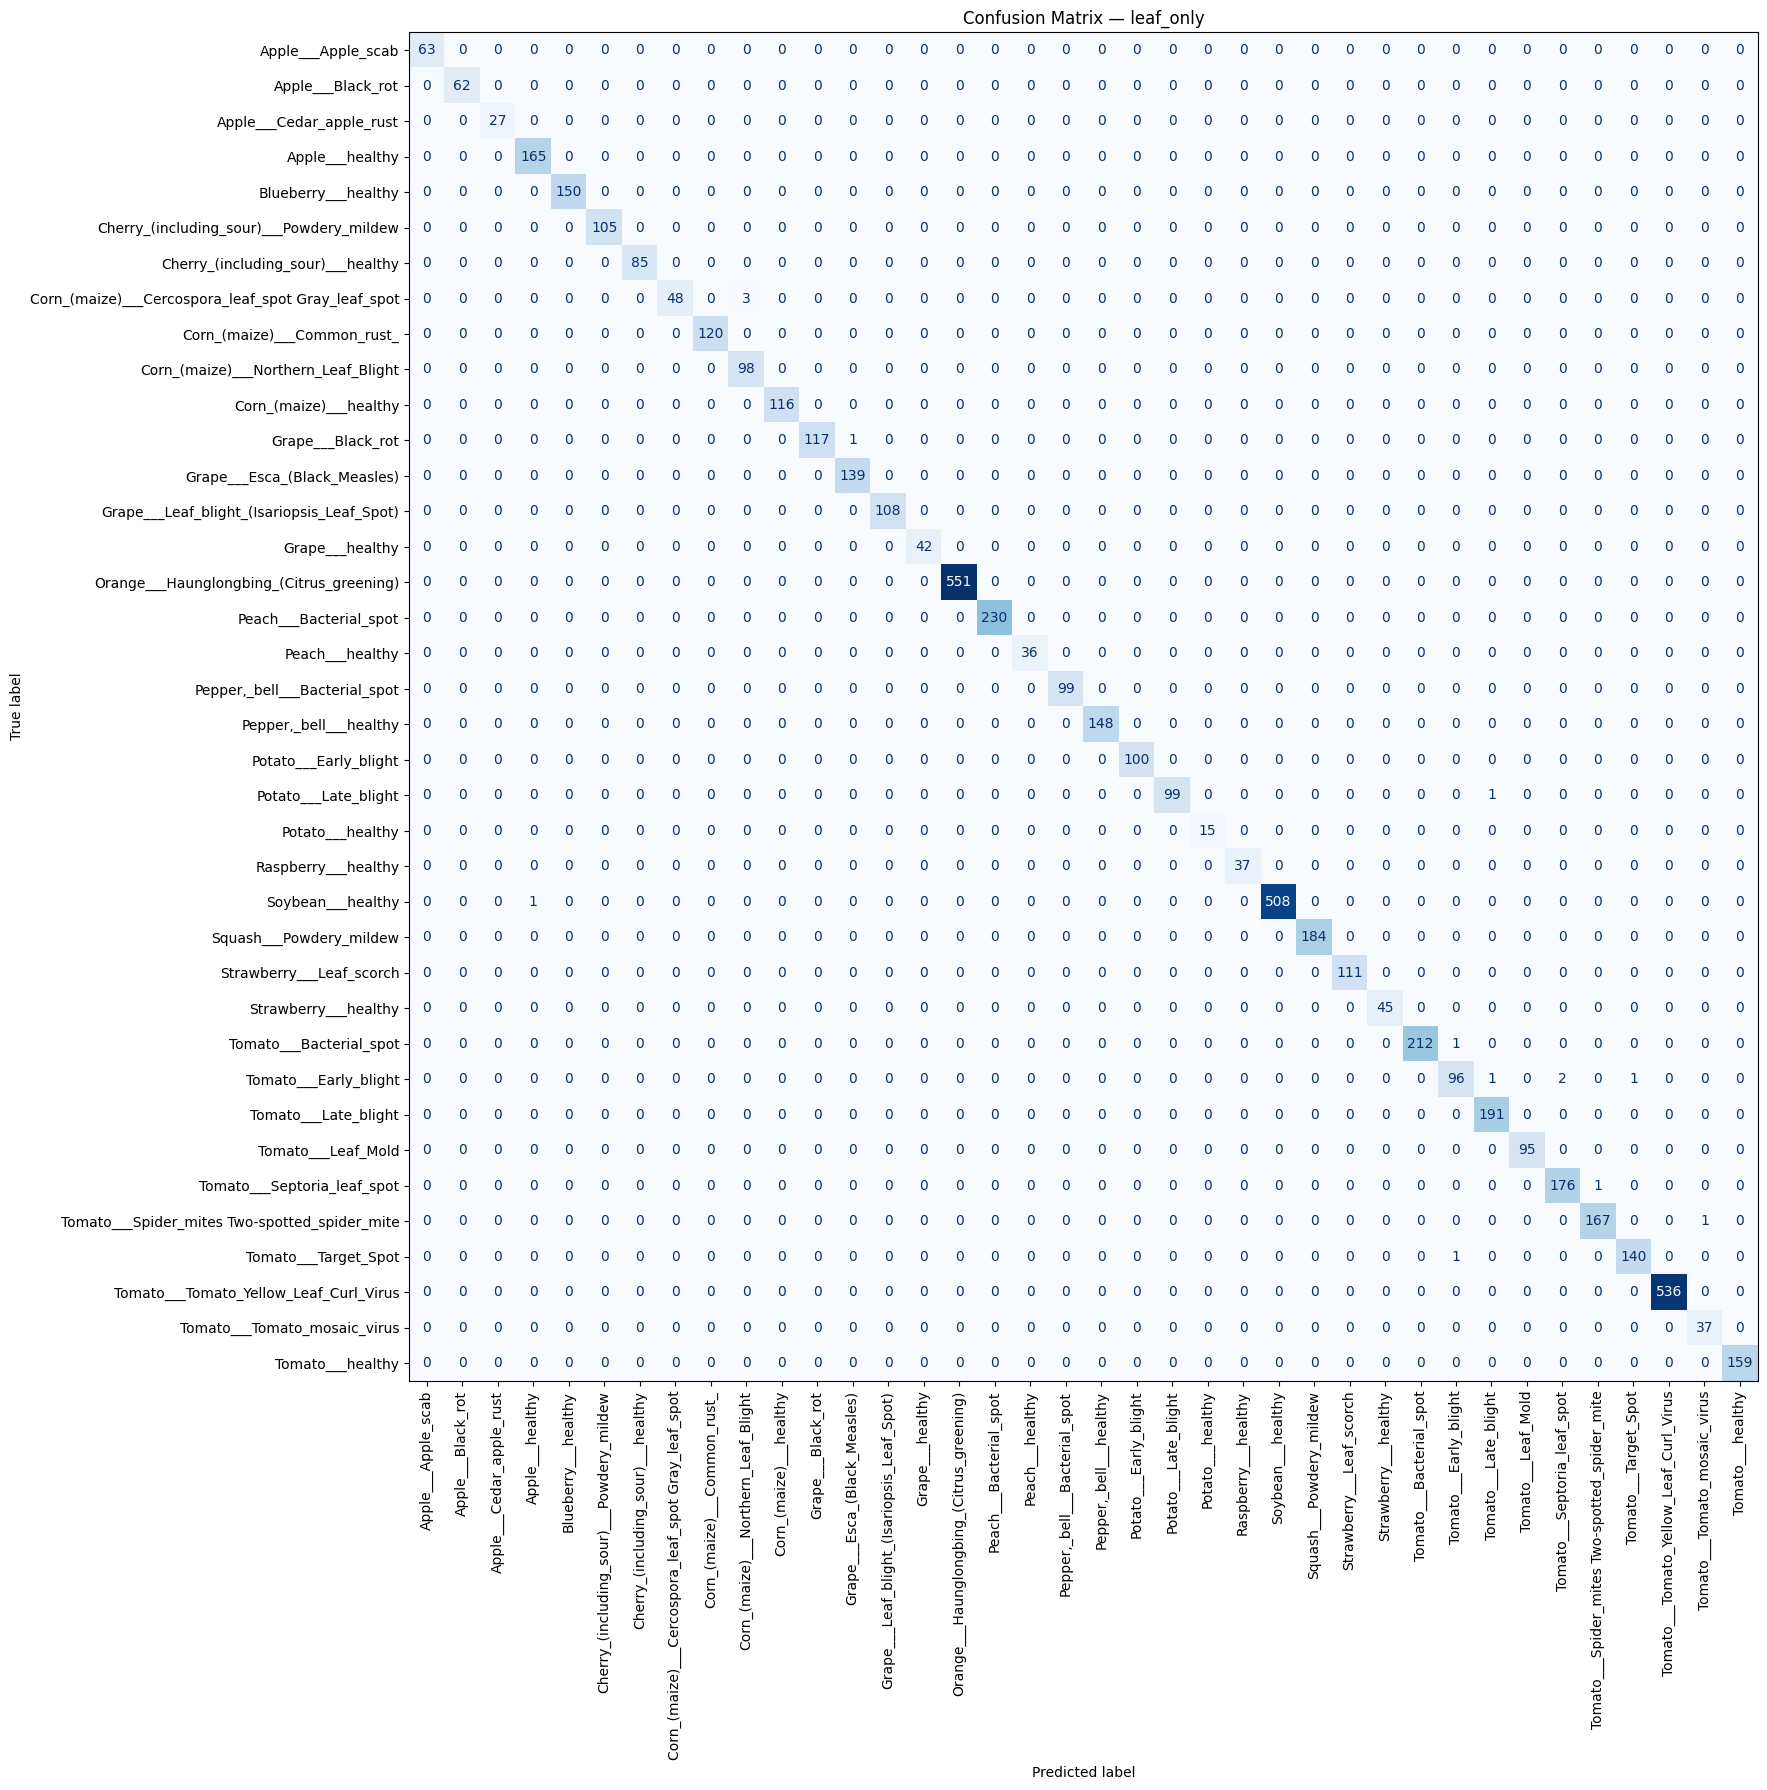

In [15]:
TEST_JSON = RESULTS_DIR/"multiview_test_metrics.json"
TEST_CSV = RESULTS_DIR/"multiview_test_metrics.csv"

with open(TEST_JSON,"w") as f:
    json.dump(
        view_results,
        f,
        indent=4
    )

rows = []

for view_name,result in view_results.items():
    row = {
        "model":"Leaf-Only EfficientNet-B0 Teacher",
        "training_view":TRAIN_VIEW,
        "test_view":view_name
    }
    row.update(result)
    rows.append(row)

pd.DataFrame(rows).to_csv(
    TEST_CSV,
    index=False
)

primary = view_outputs[
    TRAIN_VIEW
]

report = classification_report(
    primary["y_true"],
    primary["y_pred"],
    labels=list(range(38)),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

PER_CLASS_CSV = RESULTS_DIR/"per_class_test_report.csv"

pd.DataFrame(
    report
).transpose().to_csv(
    PER_CLASS_CSV
)

cm = confusion_matrix(
    primary["y_true"],
    primary["y_pred"],
    labels=list(range(38))
)

fig,ax = plt.subplots(
    figsize=(18,18)
)

ConfusionMatrixDisplay(
    cm,
    display_labels=CLASS_NAMES
).plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=False,
    values_format="d"
)

plt.title(
    f"Confusion Matrix — {TRAIN_VIEW}"
)

plt.tight_layout()

CONFUSION_PATH = (
    VISUAL_DIR/
    "confusion_matrix_primary_view.png"
)

plt.savefig(
    CONFUSION_PATH,
    dpi=220,
    bbox_inches="tight"
)

plt.show()


# STEP 16 — Training Curves and Sample Predictions

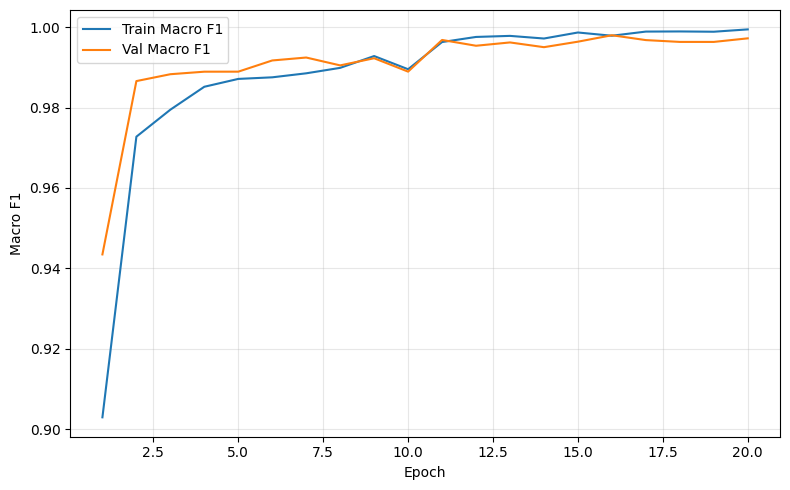

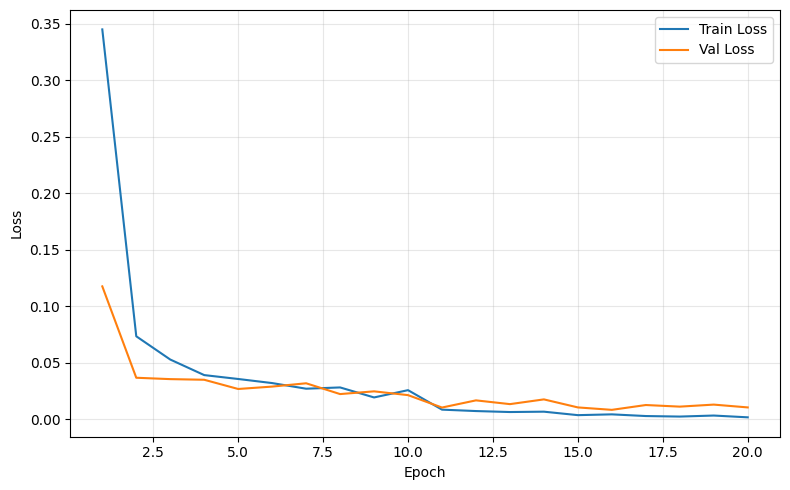

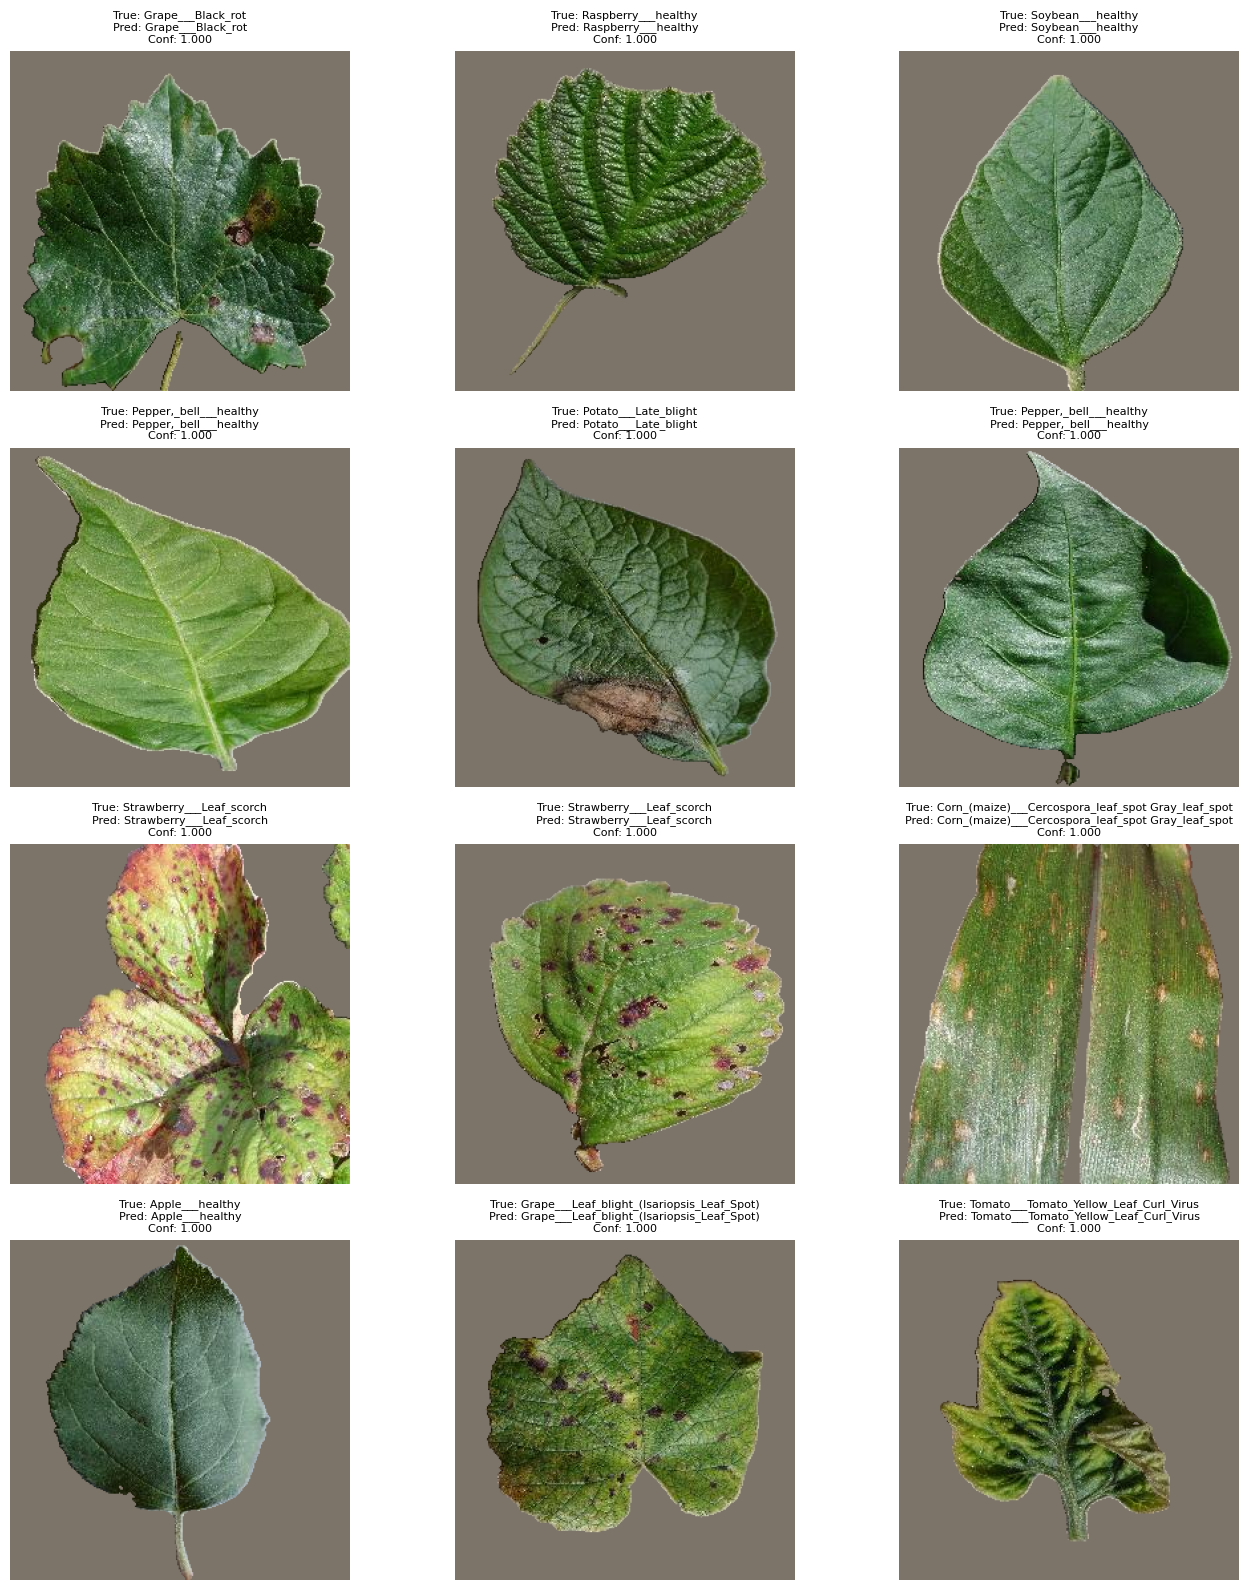

In [16]:
history_df = pd.read_csv(
    HISTORY_PATH
)

plt.figure(figsize=(8,5))

plt.plot(
    history_df["epoch"],
    history_df["train_macro_f1"],
    label="Train Macro F1"
)

plt.plot(
    history_df["epoch"],
    history_df["val_macro_f1"],
    label="Val Macro F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

F1_CURVE = VISUAL_DIR/"macro_f1_curve.png"

plt.savefig(
    F1_CURVE,
    dpi=250,
    bbox_inches="tight"
)

plt.show()


plt.figure(figsize=(8,5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Val Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

LOSS_CURVE = VISUAL_DIR/"loss_curve.png"

plt.savefig(
    LOSS_CURVE,
    dpi=250,
    bbox_inches="tight"
)

plt.show()


rng = np.random.default_rng(SEED)

indices = rng.choice(
    len(test_df),
    size=12,
    replace=False
)

fig,axes = plt.subplots(
    4,
    3,
    figsize=(14,16)
)

axes = axes.flatten()

primary_probs = primary[
    "probabilities"
]

for ax,idx in zip(
    axes,
    indices
):

    row = test_df.iloc[
        int(idx)
    ]

    image = np.array(
        Image.open(
            dataset_root/
            row["color_rel"]
        ).convert("RGB")
    )

    if TRAIN_VIEW == "leaf_only":
        image = make_leaf_only(
            image,
            get_mask(
                row["sample_id"]
            )
        )

    pred_id = int(
        primary_probs[
            idx
        ].argmax()
    )

    confidence = float(
        primary_probs[
            idx,
            pred_id
        ]
    )

    ax.imshow(image)

    ax.set_title(
        f"True: {CLASS_NAMES[int(row['class_id'])]}\n"
        f"Pred: {CLASS_NAMES[pred_id]}\n"
        f"Conf: {confidence:.3f}",
        fontsize=8
    )

    ax.axis("off")

plt.tight_layout()

PREDICTION_FIG = VISUAL_DIR/"sample_predictions.png"

plt.savefig(
    PREDICTION_FIG,
    dpi=250,
    bbox_inches="tight"
)

plt.show()


# STEP 17 — Precompute Teacher Logits for Distillation

In [17]:
all_df = df.reset_index(drop=True)

teacher_dataset = PlantVillageClassificationDataset(
    all_df,
    "leaf_only",
    eval_transform
)

teacher_loader = DataLoader(
    teacher_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

all_logits = []
all_ids = []

with torch.no_grad():

    for batch in tqdm(
        teacher_loader,
        desc="Teacher logits"
    ):

        images = batch["image"].to(
            DEVICE,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type="cuda",
            enabled=True
        ):

            logits = model(images)

        all_logits.append(
            logits.cpu().numpy().astype(
                np.float16
            )
        )

        all_ids.extend(
            list(
                batch["sample_id"]
            )
        )

all_logits = np.concatenate(
    all_logits,
    axis=0
)

TEACHER_LOGITS_PATH = (
    RESULTS_DIR/
    "teacher_logits.npz"
)

np.savez_compressed(
    TEACHER_LOGITS_PATH,
    sample_ids=np.asarray(
        all_ids,
        dtype="<U16"
    ),
    logits=all_logits
)

print(
    "Saved:",
    TEACHER_LOGITS_PATH
)

print(
    "Shape:",
    all_logits.shape
)


Teacher logits:   0%|          | 0/849 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/PlantVillage_Classification/experiments/Leaf_Only_Teacher_EfficientNetB0/results/teacher_logits.npz
Shape: (54304, 38)


# STEP 18 — Save Summary and Verify Outputs

In [18]:
summary = {
    "model":"EfficientNet-B0",
    "experiment":"Leaf-Only EfficientNet-B0 Teacher",
    "training_view":TRAIN_VIEW,
    "best_epoch":int(
        best_checkpoint["epoch"]
    ),
    "best_validation_macro_f1":float(
        best_checkpoint[
            "best_val_macro_f1"
        ]
    ),
    "multiview_test_metrics":
        view_results,
    "image_size":IMAGE_SIZE,
    "batch_size":BATCH_SIZE,
    "learning_rate":LEARNING_RATE,
    "weight_decay":WEIGHT_DECAY,
    "max_epochs":MAX_EPOCHS,
    "early_stopping_patience":
        EARLY_STOPPING_PATIENCE
}

SUMMARY_PATH = RESULTS_DIR/"experiment_summary.json"

with open(SUMMARY_PATH,"w") as f:
    json.dump(
        summary,
        f,
        indent=4
    )

required = [
    BEST_MODEL_PATH,
    LAST_CHECKPOINT_PATH,
    HISTORY_PATH,
    TEST_JSON,
    TEST_CSV,
    PER_CLASS_CSV,
    CONFUSION_PATH,
    F1_CURVE,
    LOSS_CURVE,
    PREDICTION_FIG,
    SUMMARY_PATH,
    TEACHER_LOGITS_PATH,
    COMPLETE_MARKER
]

for path in required:
    print(
        "✅" if Path(path).exists() else "❌",
        path
    )
    assert Path(path).exists()

print(
    "\n✅ EXPERIMENT COMPLETE AND RECOVERABLE."
)


✅ /content/drive/MyDrive/PlantVillage_Classification/experiments/Leaf_Only_Teacher_EfficientNetB0/checkpoints/best_model.pth
✅ /content/drive/MyDrive/PlantVillage_Classification/experiments/Leaf_Only_Teacher_EfficientNetB0/checkpoints/last_checkpoint.pth
✅ /content/drive/MyDrive/PlantVillage_Classification/experiments/Leaf_Only_Teacher_EfficientNetB0/results/training_history.csv
✅ /content/drive/MyDrive/PlantVillage_Classification/experiments/Leaf_Only_Teacher_EfficientNetB0/results/multiview_test_metrics.json
✅ /content/drive/MyDrive/PlantVillage_Classification/experiments/Leaf_Only_Teacher_EfficientNetB0/results/multiview_test_metrics.csv
✅ /content/drive/MyDrive/PlantVillage_Classification/experiments/Leaf_Only_Teacher_EfficientNetB0/results/per_class_test_report.csv
✅ /content/drive/MyDrive/PlantVillage_Classification/experiments/Leaf_Only_Teacher_EfficientNetB0/visuals/confusion_matrix_primary_view.png
✅ /content/drive/MyDrive/PlantVillage_Classification/experiments/Leaf_Only_Teac